In [26]:
import pandas as pd
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("E:\Proyecto\Pruebas\Fashion_Retail_Sales.csv")
print(df.head())

   Customer Reference ID Item Purchased  Purchase Amount (USD) Date Purchase  \
0                   4018        Handbag                 4619.0    2023-02-05   
1                   4115          Tunic                 2456.0    2023-07-11   
2                   4019       Tank Top                 2102.0    2023-03-23   
3                   4097       Leggings                 3126.0    2023-03-15   
4                   3997         Wallet                 3003.0    2022-11-27   

   Review Rating Payment Method  
0            NaN    Credit Card  
1            2.0    Credit Card  
2            4.1           Cash  
3            3.2           Cash  
4            4.7           Cash  


In [5]:
df_grouped = df.groupby('Date Purchase')['Purchase Amount (USD)'].sum()

In [10]:
print(df_grouped.head())

  Date Purchase  Purchase Amount (USD)
0    2022-10-02                  822.0
1    2022-10-03                  929.0
2    2022-10-04                 1071.0
3    2022-10-05                 1160.0
4    2022-10-06                  411.0


In [22]:
df_grouped = (
    df.groupby('Date Purchase')['Purchase Amount (USD)']
    .sum()
    .reset_index()
)

df_grouped.columns = ['fecha', 'ventas']

print(df_grouped.head())
print(df_grouped.columns)

        fecha  ventas
0  2022-10-02   822.0
1  2022-10-03   929.0
2  2022-10-04  1071.0
3  2022-10-05  1160.0
4  2022-10-06   411.0
Index(['fecha', 'ventas'], dtype='object')


In [23]:
print(df_grouped.columns)
print(df_grouped.head())

Index(['fecha', 'ventas'], dtype='object')
        fecha  ventas
0  2022-10-02   822.0
1  2022-10-03   929.0
2  2022-10-04  1071.0
3  2022-10-05  1160.0
4  2022-10-06   411.0


In [29]:
df_grouped['fecha'] = pd.to_datetime(df_grouped['fecha'])

In [33]:
print(df_grouped.dtypes)

fecha      datetime64[ns]
ventas            float64
anomaly             int32
dtype: object


In [36]:
## Rolling Mean
df_grouped['rolling_mean'] = df_grouped['ventas'].rolling(window=7).mean()

In [37]:
## DETECCION DE ANOMALÍAS
model = IsolationForest(contamination=0.05, random_state=42)

df_grouped['anomaly'] = model.fit_predict(df_grouped[['ventas']])

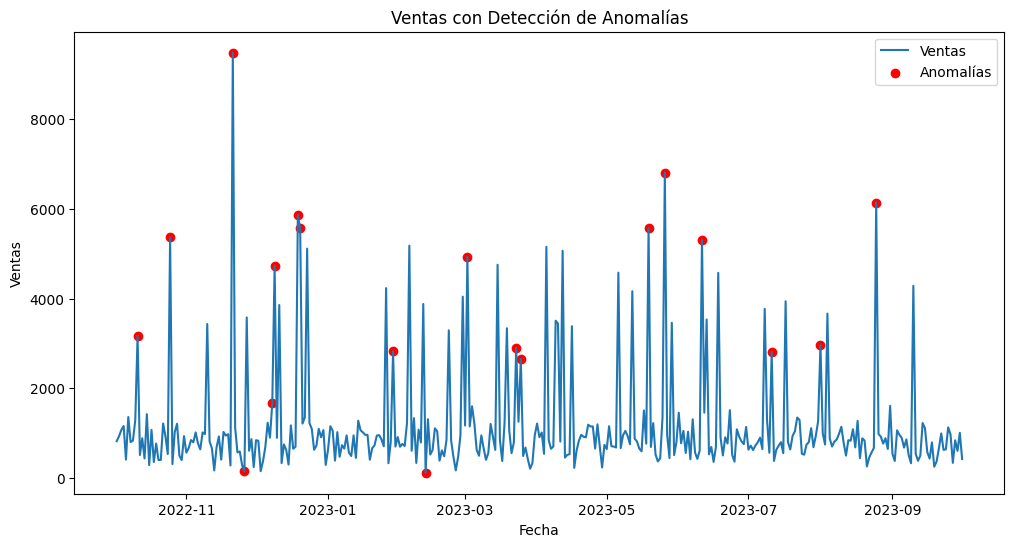

In [38]:
## Visualización de las ventas con anomalías
plt.figure(figsize=(12, 6))

plt.plot(df_grouped['fecha'], df_grouped['ventas'], label='Ventas')

##Anomalias puntos
anomalies = df_grouped[df_grouped['anomaly'] == -1]
plt.scatter(anomalies['fecha'], anomalies['ventas'], color='red', label='Anomalías')

plt.legend()
plt.title('Ventas con Detección de Anomalías')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.show()

In [35]:
for _, row in anomalies.iterrows():
    print(f"⚠️ Anomalía detectada el {pd.to_datetime(row['fecha']).date()} con ventas de {row['ventas']}")

⚠️ Anomalía detectada el 2022-10-11 con ventas de 3171.0
⚠️ Anomalía detectada el 2022-10-25 con ventas de 5362.0
⚠️ Anomalía detectada el 2022-11-21 con ventas de 9481.0
⚠️ Anomalía detectada el 2022-11-26 con ventas de 148.0
⚠️ Anomalía detectada el 2022-12-08 con ventas de 1678.0
⚠️ Anomalía detectada el 2022-12-09 con ventas de 4727.0
⚠️ Anomalía detectada el 2022-12-19 con ventas de 5861.0
⚠️ Anomalía detectada el 2022-12-20 con ventas de 5568.0
⚠️ Anomalía detectada el 2023-01-29 con ventas de 2827.0
⚠️ Anomalía detectada el 2023-02-12 con ventas de 118.0
⚠️ Anomalía detectada el 2023-03-02 con ventas de 4933.0
⚠️ Anomalía detectada el 2023-03-23 con ventas de 2900.0
⚠️ Anomalía detectada el 2023-03-25 con ventas de 2654.0
⚠️ Anomalía detectada el 2023-05-19 con ventas de 5571.0
⚠️ Anomalía detectada el 2023-05-26 con ventas de 6809.0
⚠️ Anomalía detectada el 2023-06-11 con ventas de 5311.0
⚠️ Anomalía detectada el 2023-07-11 con ventas de 2809.0
⚠️ Anomalía detectada el 2023-08-

In [39]:
if any(df_grouped['anomaly'] == -1):
    print("🚨 ALERTA: comportamiento anómalo detectado")

🚨 ALERTA: comportamiento anómalo detectado


In [31]:
df['Date Purchase'] = pd.to_datetime(df['Date Purchase'])